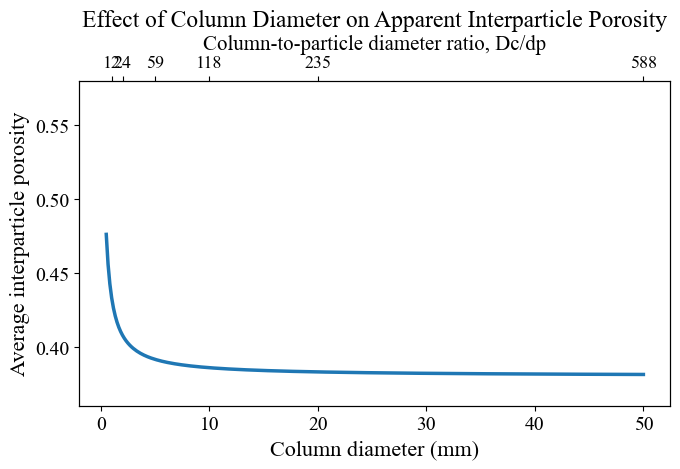

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Assumptions
# -----------------------------
# Particle diameter, e.g., chromatography resin bead diameter
dp_um = 85          # micrometers
dp = dp_um * 1e-6  # meters

# Bulk interparticle porosity away from wall
eps_bulk = 0.38

# Higher apparent porosity in wall-affected region
eps_wall = 0.55

# Effective wall-region thickness
# Approximation: about one particle diameter
wall_thickness = dp

# Column diameters to evaluate
Dc_mm = np.linspace(0.5, 50, 300)   # mm
Dc = Dc_mm * 1e-3                   # m

# Fraction of bed cross-section affected by wall
R = Dc / 2
wall_fraction = np.where(
    R > wall_thickness,
    1 - ((R - wall_thickness) / R)**2,
    1.0
)

# Average interparticle porosity
eps_avg = eps_bulk + wall_fraction * (eps_wall - eps_bulk)

# Column-to-particle diameter ratio
Dc_dp = Dc / dp

# -----------------------------
# Plot
# -----------------------------
plt.rcParams["font.family"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(7, 4.8))

ax.plot(Dc_mm, eps_avg, linewidth=2.5)
ax.set_xlabel("Column diameter (mm)", fontsize=16)
ax.set_ylabel("Average interparticle porosity", fontsize=16)
ax.set_title("Effect of Column Diameter on Apparent Interparticle Porosity", fontsize=17)

ax.tick_params(axis="both", labelsize=14)
ax.set_ylim(0.36, 0.58)

# Optional second x-axis: Dc/dp
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
tick_mm = np.array([1, 2, 5, 10, 20, 50])
ax2.set_xticks(tick_mm)
ax2.set_xticklabels([f"{x*1e-3/dp:.0f}" for x in tick_mm])
ax2.set_xlabel("Column-to-particle diameter ratio, Dc/dp", fontsize=15)
ax2.tick_params(axis="x", labelsize=13)

plt.tight_layout()
plt.show()

## Four different particle sizes 

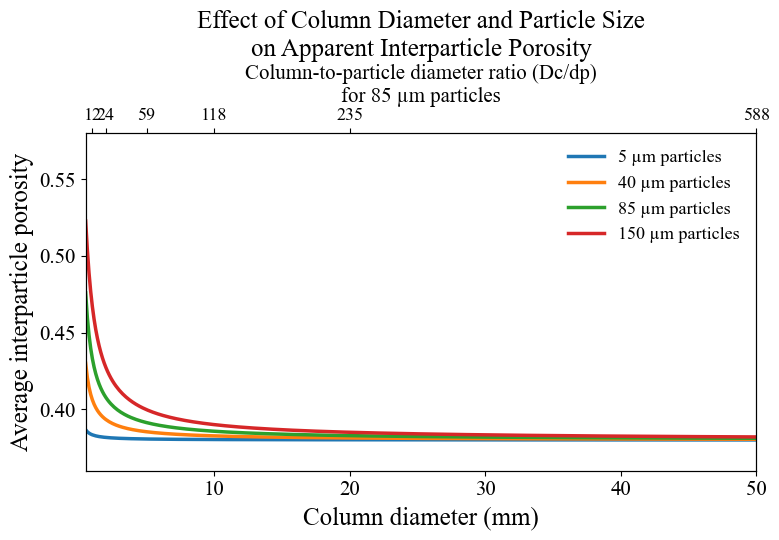

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# Parameters
# ----------------------------------------

# Particle sizes in micrometers
particle_sizes_um = [5, 40, 85, 150]

# Bulk interparticle porosity
eps_bulk = 0.38

# Wall-region porosity
eps_wall = 0.55

# Column diameter range (mm)
Dc_mm = np.linspace(0.5, 50, 400)
Dc = Dc_mm * 1e-3  # convert to meters

# ----------------------------------------
# Plot formatting
# ----------------------------------------

plt.rcParams["font.family"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(8, 5.5))

# ----------------------------------------
# Calculate porosity profiles
# ----------------------------------------

for dp_um in particle_sizes_um:

    # Convert particle size to meters
    dp = dp_um * 1e-6

    # Approximate wall-effect thickness
    wall_thickness = dp

    # Column radius
    R = Dc / 2

    # Fraction of wall-affected region
    wall_fraction = np.where(
        R > wall_thickness,
        1 - ((R - wall_thickness) / R) ** 2,
        1.0
    )

    # Average apparent interparticle porosity
    eps_avg = eps_bulk + wall_fraction * (eps_wall - eps_bulk)

    # Plot
    ax.plot(
        Dc_mm,
        eps_avg,
        linewidth=2.5,
        label=f"{dp_um} µm particles"
    )

# ----------------------------------------
# Axis labels and styling
# ----------------------------------------

ax.set_xlabel("Column diameter (mm)", fontsize=18)
ax.set_ylabel("Average interparticle porosity", fontsize=18)

ax.set_title(
    "Effect of Column Diameter and Particle Size\non Apparent Interparticle Porosity",
    fontsize=18
)

ax.tick_params(axis='both', labelsize=15)

ax.set_xlim(0.5, 50)
ax.set_ylim(0.36, 0.58)

# Remove grid for PPT-style figure
ax.grid(False)

# Legend
ax.legend(
    fontsize=13,
    frameon=False,
    loc='upper right'
)

# ----------------------------------------
# Secondary axis: Dc/dp for 85 µm particles
# ----------------------------------------

reference_dp = 85e-6

ax2 = ax.twiny()

ax2.set_xlim(ax.get_xlim())

tick_mm = np.array([1, 2, 5, 10, 20, 50])

ax2.set_xticks(tick_mm)

ax2.set_xticklabels(
    [f"{(x * 1e-3) / reference_dp:.0f}" for x in tick_mm]
)

ax2.set_xlabel(
    "Column-to-particle diameter ratio (Dc/dp)\nfor 85 µm particles",
    fontsize=15
)

ax2.tick_params(axis='x', labelsize=13)

# ----------------------------------------
# Layout
# ----------------------------------------

plt.tight_layout()

plt.show()

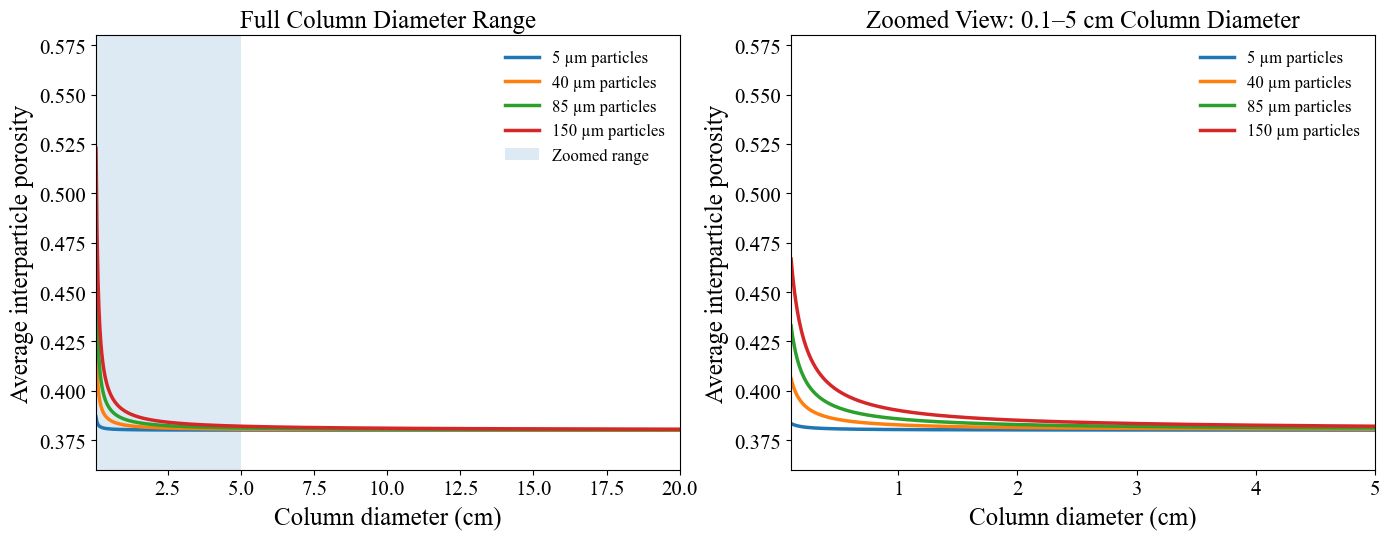

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# Parameters
# ----------------------------------------

particle_sizes_um = [5, 40, 85, 150]

eps_bulk = 0.38
eps_wall = 0.55

# Full range in cm
Dc_cm_full = np.linspace(0.05, 20, 600)   # 0.05 cm to 20 cm
Dc_full = Dc_cm_full * 1e-2               # convert cm to meters

# Zoomed range in cm
Dc_cm_zoom = np.linspace(0.1, 5, 500)     # 0.1 cm to 5 cm
Dc_zoom = Dc_cm_zoom * 1e-2               # convert cm to meters

plt.rcParams["font.family"] = "Times New Roman"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# ----------------------------------------
# Function to calculate apparent porosity
# ----------------------------------------

def calculate_porosity(Dc, dp_um):
    dp = dp_um * 1e-6
    wall_thickness = dp
    R = Dc / 2

    wall_fraction = np.where(
        R > wall_thickness,
        1 - ((R - wall_thickness) / R) ** 2,
        1.0
    )

    eps_avg = eps_bulk + wall_fraction * (eps_wall - eps_bulk)
    return eps_avg

# ----------------------------------------
# Left plot: original full range
# ----------------------------------------

for dp_um in particle_sizes_um:
    eps_avg = calculate_porosity(Dc_full, dp_um)

    ax1.plot(
        Dc_cm_full,
        eps_avg,
        linewidth=2.5,
        label=f"{dp_um} µm particles"
    )

# Highlight zoomed region in original plot
ax1.axvspan(
    0.1,
    5,
    alpha=0.15,
    label="Zoomed range"
)

ax1.set_xlabel("Column diameter (cm)", fontsize=18)
ax1.set_ylabel("Average interparticle porosity", fontsize=18)

ax1.set_title(
    "Full Column Diameter Range",
    fontsize=18
)

ax1.set_xlim(0.05, 20)
ax1.set_ylim(0.36, 0.58)

ax1.tick_params(axis="both", labelsize=15)
ax1.grid(False)

ax1.legend(
    fontsize=12,
    frameon=False,
    loc="upper right"
)

# ----------------------------------------
# Right plot: zoomed range up to 5 cm
# ----------------------------------------

for dp_um in particle_sizes_um:
    eps_avg = calculate_porosity(Dc_zoom, dp_um)

    ax2.plot(
        Dc_cm_zoom,
        eps_avg,
        linewidth=2.5,
        label=f"{dp_um} µm particles"
    )

ax2.set_xlabel("Column diameter (cm)", fontsize=18)
ax2.set_ylabel("Average interparticle porosity", fontsize=18)

ax2.set_title(
    "Zoomed View: 0.1–5 cm Column Diameter",
    fontsize=18
)

ax2.set_xlim(0.1, 5)
ax2.set_ylim(0.36, 0.58)

ax2.tick_params(axis="both", labelsize=15)
ax2.grid(False)

ax2.legend(
    fontsize=12,
    frameon=False,
    loc="upper right"
)

# ----------------------------------------
# Layout
# ----------------------------------------

plt.tight_layout()
plt.show()

## Mechanistic understanding why axial disperssion is high at smaller diameter column
As the chromatographic column diameter decreases, the wall-affected region occupies a larger fraction of the packed bed volume. This leads to increased local interparticle porosity near the column wall and generates radial velocity heterogeneity. Solute molecules traveling through higher-porosity regions experience faster local velocities, increasing eddy dispersion and overall axial dispersion. The effect becomes more pronounced at low column-to-particle diameter ratios ((D_c/d_p)) and can contribute to broader chromatographic peaks in mini-columns and RoboColumns compared with larger laboratory-scale columns.


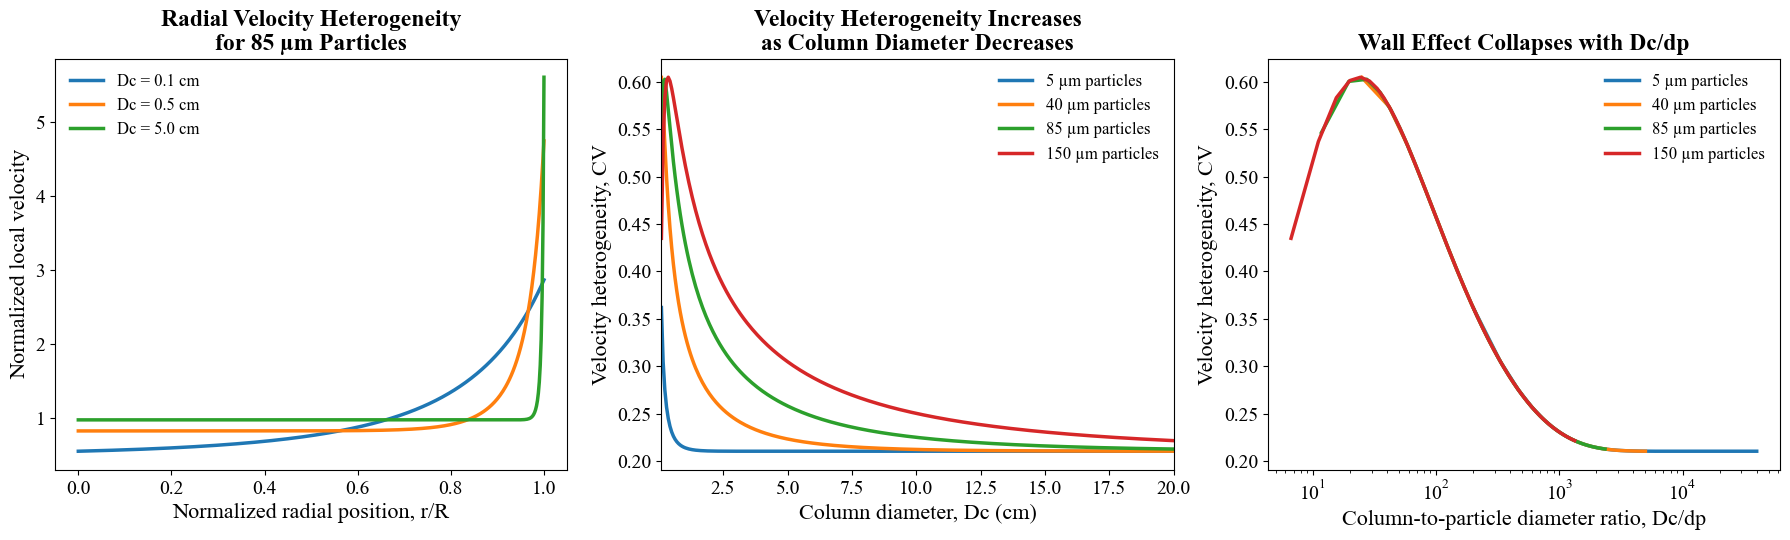

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# GLOBAL FONT SETTINGS
# --------------------------------------------------

plt.rcParams["font.family"] = "Times New Roman"

plt.rcParams["axes.titlesize"] = 17
plt.rcParams["axes.titleweight"] = "bold"

plt.rcParams["axes.labelsize"] = 16

plt.rcParams["xtick.labelsize"] = 14
plt.rcParams["ytick.labelsize"] = 14

plt.rcParams["legend.fontsize"] = 12

# --------------------------------------------------
# Model assumptions
# --------------------------------------------------

particle_sizes_um = [5, 40, 85, 150]

eps_bulk = 0.38
eps_wall = 0.55

# Wall-effect thickness proportionality
wall_factor = 2.0

# Column diameter range in cm
Dc_cm = np.linspace(0.1, 20, 300)

# --------------------------------------------------
# Helper functions
# --------------------------------------------------

def porosity_profile(r, R, dp):

    wall_length = wall_factor * dp

    eps_r = eps_bulk + \
            (eps_wall - eps_bulk) * \
            np.exp(-(R - r) / wall_length)

    return eps_r


def local_velocity_from_porosity(eps_r):

    # Kozeny-Carman type dependence
    k_r = eps_r**3 / (1 - eps_r)**2

    u_r = k_r / np.mean(k_r)

    return u_r


def velocity_heterogeneity(Dc_cm, dp_um):

    dp = dp_um * 1e-6
    Dc = Dc_cm * 1e-2
    R = Dc / 2

    cv_values = []

    for Ri in R:

        r = np.linspace(0, Ri, 500)

        eps_r = porosity_profile(r, Ri, dp)

        u_r = local_velocity_from_porosity(eps_r)

        cv = np.std(u_r) / np.mean(u_r)

        cv_values.append(cv)

    return np.array(cv_values)

# --------------------------------------------------
# Figure with three panels
# --------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5)
)

# --------------------------------------------------
# PANEL 1
# Radial velocity profiles
# --------------------------------------------------

dp_um_ref = 85
dp_ref = dp_um_ref * 1e-6

selected_Dc_cm = [0.1, 0.5, 5.0]

for D in selected_Dc_cm:

    R = (D * 1e-2) / 2

    r = np.linspace(0, R, 500)

    r_normalized = r / R

    eps_r = porosity_profile(r, R, dp_ref)

    u_r = local_velocity_from_porosity(eps_r)

    axes[0].plot(
        r_normalized,
        u_r,
        linewidth=2.5,
        label=f"Dc = {D} cm"
    )

axes[0].set_xlabel(
    "Normalized radial position, r/R"
)

axes[0].set_ylabel(
    "Normalized local velocity"
)

axes[0].set_title(
    "Radial Velocity Heterogeneity\nfor 85 µm Particles"
)

axes[0].legend(
    frameon=False,
    prop={"family": "Times New Roman", "size": 12}
)

axes[0].grid(False)

# --------------------------------------------------
# PANEL 2
# Velocity heterogeneity vs column diameter
# --------------------------------------------------

for dp_um in particle_sizes_um:

    cv = velocity_heterogeneity(Dc_cm, dp_um)

    axes[1].plot(
        Dc_cm,
        cv,
        linewidth=2.5,
        label=f"{dp_um} µm particles"
    )

axes[1].set_xlabel(
    "Column diameter, Dc (cm)"
)

axes[1].set_ylabel(
    "Velocity heterogeneity, CV"
)

axes[1].set_title(
    "Velocity Heterogeneity Increases\nas Column Diameter Decreases"
)

axes[1].set_xlim(0.1, 20)

axes[1].legend(
    frameon=False,
    prop={"family": "Times New Roman", "size": 12}
)

axes[1].grid(False)

# --------------------------------------------------
# PANEL 3
# Velocity heterogeneity vs Dc/dp
# --------------------------------------------------

for dp_um in particle_sizes_um:

    cv = velocity_heterogeneity(Dc_cm, dp_um)

    dp_cm = dp_um * 1e-4

    Dc_dp = Dc_cm / dp_cm

    axes[2].plot(
        Dc_dp,
        cv,
        linewidth=2.5,
        label=f"{dp_um} µm particles"
    )

axes[2].set_xscale("log")

axes[2].set_xlabel(
    "Column-to-particle diameter ratio, Dc/dp"
)

axes[2].set_ylabel(
    "Velocity heterogeneity, CV"
)

axes[2].set_title(
    "Wall Effect Collapses with Dc/dp"
)

axes[2].legend(
    frameon=False,
    prop={"family": "Times New Roman", "size": 12}
)

axes[2].grid(False)

# --------------------------------------------------
# Tick font formatting
# --------------------------------------------------

for ax in axes:

    for label in ax.get_xticklabels():
        label.set_fontname("Times New Roman")

    for label in ax.get_yticklabels():
        label.set_fontname("Times New Roman")

# --------------------------------------------------
# Layout and save
# --------------------------------------------------

plt.tight_layout()

plt.savefig(
    "velocity_heterogeneity_wall_effect.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()